# Data Mining Project: Customer Behavioral Segmentation and Profiling

### Dataset Introduction
This project involves the analysis of a dataset related to a **charity group**. The dataset contains **general information about the members** and **a list of their donations over a specific period**, stored in two separate files named **BenefactorsData.csv** and **TransactionalData.csv**.

* **BenefactorsData.csv :** This file includes the **membership ID**, **gender**, **State**, **date of birth**, and **how members became acquainted** with the charity group.
* **TransactionalData.csv :** This file includes the **unique transaction code** along with the **date** and **amount of the donation**, and the **type of donation** made by each group member.

### Problem

The charity group is interested in using data science tools to design marketing strategies aimed at determining the appropriate target group and profiling the behavioral patterns of its members. The goal is to design and implement advertising campaigns. The expected outcomes of this project are:

* **Segmentation of Members:** Based on donation history and behavioral indicators, members can be divided into several manageable groups. This segmentation will reveal the current behavioral patterns of the members.

* **Target Market Identification:** By understanding the behavioral patterns, the charity group can select suitable behavioral patterns for campaign implementation.

* **Profiling Members:** Exploring the relationship between initial member information (such as gender, age, etc.) and identified behavioral patterns. This profiling will provide insights into key characteristics of potential benefactors, helping the charity group in targeting and engaging with them effectively.



**Importing Required Libraries**

In [1]:
import pandas as pd 
import numpy as np
import re 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import random 
warnings.filterwarnings("ignore")
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

**Read data**

In [2]:
df_Benefactors = pd.read_csv('BenefactorsData.csv')
df_Benefactors

,UserID,Gender,State,BirthDate,acquaintanceType
0,3,زن,تهران,1363-08-16,آشنایان
1,8,مرد,تهران,1364-06-24,آشنایان
2,14,مرد,تهران,1356-07-07,آشنایان
3,17,زن,تهران,1325-07-23,آشنایان
4,18,زن,تهران,1334-10-06,آشنایان
...,...,...,...,...,...
278381,262139,مرد,تهران,1357-04-10,اپلیکیشن
278382,262140,مرد,تهران,1354-10-01,اپلیکیشن
278383,262141,مرد,فارس,1373-05-31,اپلیکیشن
278384,262142,زن,البرز,NaN,تبلیغات


**checking BirthDate format and inconsistency**

In [13]:
BirthDate_ok_pattern_values=[]
BirthDate_not_ok_pattern_values=[]

for i in  df_Benefactors['BirthDate'].dropna().values : 
        if re.search(r"^\d\d\d\d-\d\d-\d\d$", i):  
                BirthDate_ok_pattern_values.append(i)
        else:
            BirthDate_not_ok_pattern_values.append(i)
            
if len(BirthDate_not_ok_pattern_values) == 0:
    print('the BirthDate format of all our records that are not missing is ok')
else:
    print(BirthDate_not_ok_pattern_values)

the BirthDate format of all our records that are not missing is ok


**Convert date of BirthDate to year of BirthDate**

In [14]:
df_Benefactors['BirthDate'] = df_Benefactors['BirthDate'].apply(lambda x: int(x[0:4]) if not pd.isna(x)  else x)
print("Unique values of BirthDate :\n", df_Benefactors['BirthDate'].sort_values().unique())
print("\nNull counts in the BirthDate field : ", df_Benefactors.BirthDate.isnull().sum())

Unique values of BirthDate :
 [1289. 1290. 1292. 1293. 1296. 1297. 1298. 1299. 1300. 1301. 1302. 1303.
 1304. 1305. 1306. 1307. 1308. 1309. 1310. 1311. 1312. 1313. 1314. 1315.
 1316. 1317. 1318. 1319. 1320. 1321. 1322. 1323. 1324. 1325. 1326. 1327.
 1328. 1329. 1330. 1331. 1332. 1333. 1334. 1335. 1336. 1337. 1338. 1339.
 1340. 1341. 1342. 1343. 1344. 1345. 1346. 1347. 1348. 1349. 1350. 1351.
 1352. 1353. 1354. 1355. 1356. 1357. 1358. 1359. 1360. 1361. 1362. 1363.
 1364. 1365. 1366. 1367. 1368. 1369. 1370. 1371. 1372. 1373. 1374. 1375.
 1376. 1377. 1378. 1379. 1380. 1381. 1382. 1383. 1384. 1385. 1386. 1387.
 1388. 1389. 1390. 1391. 1392. 1393. 1394. 1395. 1396. 1397. 1398. 1399.
 1403. 1425. 1563. 1631. 1632. 1635. 1638. 1656. 1658. 1665.   nan]

Null counts in the BirthDate field :  56569


**remove out of logical range values**

In [15]:
df_Benefactors['BirthDate'] = df_Benefactors['BirthDate'].apply(lambda x : x if x>1300 and x<1403 else None)
print("Unique values of BirthDate :\n", df_Benefactors['BirthDate'].sort_values().unique())
print("\nNull counts in the BirthDate field : ", df_Benefactors.BirthDate.isnull().sum())

Unique values of BirthDate :
 [1301. 1302. 1303. 1304. 1305. 1306. 1307. 1308. 1309. 1310. 1311. 1312.
 1313. 1314. 1315. 1316. 1317. 1318. 1319. 1320. 1321. 1322. 1323. 1324.
 1325. 1326. 1327. 1328. 1329. 1330. 1331. 1332. 1333. 1334. 1335. 1336.
 1337. 1338. 1339. 1340. 1341. 1342. 1343. 1344. 1345. 1346. 1347. 1348.
 1349. 1350. 1351. 1352. 1353. 1354. 1355. 1356. 1357. 1358. 1359. 1360.
 1361. 1362. 1363. 1364. 1365. 1366. 1367. 1368. 1369. 1370. 1371. 1372.
 1373. 1374. 1375. 1376. 1377. 1378. 1379. 1380. 1381. 1382. 1383. 1384.
 1385. 1386. 1387. 1388. 1389. 1390. 1391. 1392. 1393. 1394. 1395. 1396.
 1397. 1398. 1399.   nan]

Null counts in the BirthDate field :  57184


**convert year of BirthDate to age**

In [17]:
df_Benefactors['BirthDate'] = df_Benefactors['BirthDate'].apply(lambda x : 1403-x if x else None)
df_Benefactors.rename(columns={'BirthDate': 'Age'}, inplace=True)

,UserID,Gender,State,Age,acquaintanceType
0,3,زن,تهران,40.0,آشنایان
1,8,مرد,تهران,39.0,آشنایان
2,14,مرد,تهران,47.0,آشنایان
3,17,زن,تهران,78.0,آشنایان
4,18,زن,تهران,69.0,آشنایان
...,...,...,...,...,...
278381,262139,مرد,تهران,46.0,اپلیکیشن
278382,262140,مرد,تهران,49.0,اپلیکیشن
278383,262141,مرد,فارس,30.0,اپلیکیشن
278384,262142,زن,البرز,NaN,تبلیغات


**Check Data Types and Missing Values**

In [18]:
print(df_Benefactors.dtypes)
print("-" * 60)
print("Null counts :\n",df_Benefactors.isnull().sum())

UserID                int64
Gender               object
State                object
Age                 float64
acquaintanceType     object
dtype: object
------------------------------------------------------------
Null counts :
 UserID                  0
Gender                237
State                   0
Age                 57184
acquaintanceType        0
dtype: int64


**Inconsistent checking**

In [20]:
print(df_Benefactors['Gender'].unique(), "\n")
print("-+" * 50, "\n")
print(df_Benefactors['State'].unique(), "\n")
print("-+" * 50, "\n")
print(df_Benefactors['acquaintanceType'].unique(), "\n")

['زن' 'مرد' nan] 

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

['تهران' 'چهار محال و بختیاری' 'البرز' 'گیلان' 'خراسان رضوی' 'کرمان'
 'مازندران' 'سیستان و بلوچستان' 'قزوین' 'لرستان' 'کرمانشاه' 'یزد'
 'خوزستان' 'گلستان' 'خارج از كشور' 'آذربایجان شرقی' 'فارس' 'ایلام'
 'کردستان' 'سمنان' 'قم' 'آذربایجان غربی' 'اصفهان' 'خراسان جنوبی' 'بوشهر'
 'مرکزی' 'زنجان' 'هرمزگان' 'اردبیل' 'همدان' 'کهکیلوییه و بویر احمد'
 'خراسان شمالی' 'نامشخص'] 

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

['آشنایان' 'برنامه های عمومی' 'نامشخص' 'نمایندگی ها' 'تبلیغات' 'اپلیکیشن'
 'وبسایت' 'پیامک'] 



 **Transliteration**

In [22]:
acquaintanceType_translated_values_dict = {'پیامک':"payamak", 'برنامه های عمومی':"barnamehaye_omomi",
                                           'نمایندگی ها':"namayandegi_ha", 'اپلیکیشن':"application",
                                           'وبسایت':"website", 'تبلیغات':"tablighat", 'آشنایان':"ashnayan",
                                           'نامشخص':None}
 
State_translated_values_dict ={'چهار محال و بختیاری':"chahar-mahal_o_bakhtiari", 'البرز':"alborz", 'گیلان':"gilan",
                               'خراسان رضوی':"khorasan-razavi", 'کرمان':"kerman", 'تهران':"tehran", 
                               'سیستان و بلوچستان':"sistan_va_balochestan", 'قزوین':"ghazvin", 'لرستان':"lorestan",  
                               'کرمانشاه':"kermanshah", 'یزد':"yazd", 'مازندران':"mazandaran", 'خوزستان':"khozestan",
                               'گلستان':"golestan", 'خارج از كشور':"kharej-az-keshvar", 'آذربایجان شرقی':"azarbayejan-sharghi",
                               'فارس':"fars", 'ایلام':"ilam", 'کردستان':"kordestan" ,'سمنان':"semnan", 'قم':"ghom",
                               'آذربایجان غربی':"azarbayejan-gharbi", 'اصفهان':"isfahan", 'خراسان جنوبی':"khorasan-jonobi",
                               'بوشهر':"boshehr", 'مرکزی':"markazi", 'زنجان':"zanjan", 'هرمزگان':"hormozgan",   
                               'اردبیل':"ardabil", 'همدان':"hamedan", 'کهکیلوییه و بویر احمد':"kohkiloye-va-boyer-ahmad",
                               'خراسان شمالی':"khorasan-shomali", 'نامشخص':None}


df_Benefactors.iloc[ : , 1] = df_Benefactors.iloc[ : , 1].apply(lambda x: 'male' if x == "مرد" else 'female' if x == "زن" else None)
df_Benefactors.iloc[ : , 2] = df_Benefactors.iloc[ : ,2].apply(lambda x : State_translated_values_dict.get(x))
df_Benefactors.iloc[ : , 4] = df_Benefactors.iloc[ : ,4].apply(lambda x : acquaintanceType_translated_values_dict.get(x))


,UserID,Gender,State,Age,acquaintanceType
0,3,female,tehran,40.0,ashnayan
1,8,male,tehran,39.0,ashnayan
2,14,male,tehran,47.0,ashnayan
3,17,female,tehran,78.0,ashnayan
4,18,female,tehran,69.0,ashnayan
...,...,...,...,...,...
278381,262139,male,tehran,46.0,application
278382,262140,male,tehran,49.0,application
278383,262141,male,fars,30.0,application
278384,262142,female,alborz,NaN,tablighat


**Inconsistent checking**

In [23]:
print(df_Benefactors['Gender'].unique(), "\n")
print("-+" * 50, "\n")
print(df_Benefactors['State'].unique(), "\n")
print("-+" * 50, "\n")
print(df_Benefactors['acquaintanceType'].unique(), "\n")

['female' 'male' None] 

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

['tehran' 'chahar-mahal_o_bakhtiari' 'alborz' 'gilan' 'khorasan-razavi'
 'kerman' 'mazandaran' 'sistan_va_balochestan' 'ghazvin' 'lorestan'
 'kermanshah' 'yazd' 'khozestan' 'golestan' 'kharej-az-keshvar'
 'azarbayejan-sharghi' 'fars' 'ilam' 'kordestan' 'semnan' 'ghom'
 'azarbayejan-gharbi' 'isfahan' 'khorasan-jonobi' 'boshehr' 'markazi'
 'zanjan' 'hormozgan' 'ardabil' 'hamedan' 'kohkiloye-va-boyer-ahmad'
 'khorasan-shomali' None] 

-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

['ashnayan' 'barnamehaye_omomi' None 'namayandegi_ha' 'tablighat'
 'application' 'website' 'payamak'] 



**Check Missing Values**

In [24]:
print("Null counts :\n",df_Benefactors.isnull().sum())

Null counts :
 UserID                   0
Gender                 237
State                   15
Age                  57184
acquaintanceType    131614
dtype: int64


### Feature Screening

In [25]:
# Calculate the coefficient of variation for "Age" column
coefficient_of_variation = df_Benefactors['Age'].std() / df_Benefactors['Age'].mean()
print('coefficient of variation for "Age" column is ', coefficient_of_variation)

coefficient of variation for "Age" column is  0.2914934042573497


    >0.1 is ok

In [26]:
# Calculate the percentage of the mode category for categorical columns

print("percentage of the mode category for 'Gender': ", df_Benefactors['Gender'].value_counts().max() / df_Benefactors.shape[0] * 100)
print("Null counts of Gender:",df_Benefactors['Gender'].isnull().sum() / df_Benefactors.shape[0] * 100, "\n\n")

print("percentage of the mode category for 'State': ", df_Benefactors['State'].value_counts().max() / df_Benefactors.shape[0] * 100)
print("Null counts of State:",df_Benefactors['State'].isnull().sum() / df_Benefactors.shape[0] * 100, "\n\n")

print("percentage of the mode category for 'acquaintanceType': ", df_Benefactors['acquaintanceType'].value_counts().max() / df_Benefactors.shape[0] * 100)
print("Null counts of acquaintanceType:",df_Benefactors['acquaintanceType'].isnull().sum() / df_Benefactors.shape[0] * 100, "\n\n")

percentage of the mode category for 'Gender':  51.43829071864246
Null counts of Gender: 0.08513359148807771 


percentage of the mode category for 'State':  82.28143656649401
Null counts of State: 0.00538820199291631 


percentage of the mode category for 'acquaintanceType':  12.805241642898709
Null counts of acquaintanceType: 47.27752113971248 




<95 is ok

In [27]:
# Calculate the percentage of uniqueness categories in categorical variables
print("percentage of uniqueness in 'Gender': ", (len(df_Benefactors['Gender'].unique()) -  int(True in df_Benefactors['Gender'].isnull().unique())) / df_Benefactors.shape[0] * 100, "\n")
print("percentage of uniqueness in 'State': ", (len(df_Benefactors['State'].unique()) -  int(True in df_Benefactors['State'].isnull().unique())) / df_Benefactors.shape[0] * 100, "\n")
print("percentage of uniqueness in 'acquaintanceType': ", (len(df_Benefactors['acquaintanceType'].unique()) -  int(True in df_Benefactors['acquaintanceType'].isnull().unique())) / df_Benefactors.shape[0] * 100, "\n")


percentage of uniqueness in 'Gender':  0.0007184269323888414 

percentage of uniqueness in 'State':  0.011494830918221462 

percentage of uniqueness in 'acquaintanceType':  0.002514494263360945 



<90 is ok

 **find  duplicated rows**

In [28]:
if len(df_Benefactors[df_Benefactors.duplicated(keep='last')]) == 0:
    print("We do not have any duplicate rows !!")
else : 
    print(df_Benefactors[df_Benefactors.duplicated(keep='last')])

We do not have any duplicate rows !!


**Outlier Detection --> *one dimentional method* (IQR)**

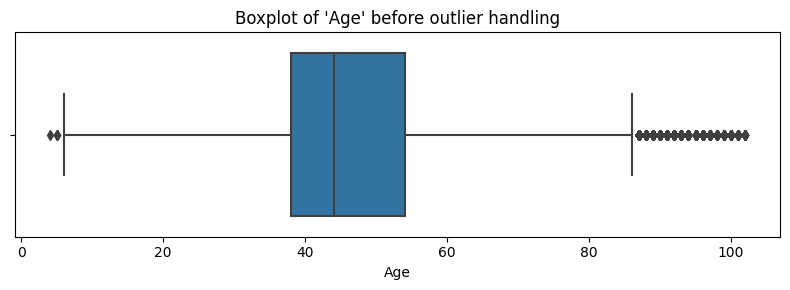

Identified outliers: 1475
Unique outlier values:
 [4.0, 5.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0]


In [29]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,3))

# boxplot of 'Age'
sns.boxplot(x='Age', data=df_Benefactors, ax=axes, whis=2)
axes.set_title("Boxplot of 'Age' before outlier handling")

# Adjust layout
plt.tight_layout()

# show the plots
plt.show()

# one dimentional method(IQr)
# calculate interquartile range
q25, q75 = df_Benefactors['Age'].quantile(0.25), df_Benefactors['Age'].quantile(0.75)
iqr = q75 - q25
  
# calculate the outlier cutoff
cut_off = 2 * iqr 
lower, upper = q25 - cut_off, q75 + cut_off
    
# identify outliers
outliers_of_Age= [x for x in df_Benefactors['Age'] if x < lower or x > upper]
print('Identified outliers: {}'.format(len(outliers_of_Age)))
print('Unique outlier values:\n {}'.format(sorted(set(outliers_of_Age))))

**Outlier Handling**

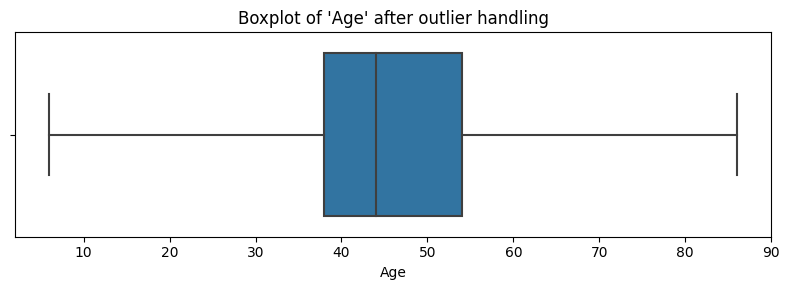

In [30]:
# Remove rows containing outliers
df_Benefactors = df_Benefactors.drop(df_Benefactors[df_Benefactors['Age'].isin(outliers_of_Age)].index)

# Boxplot of 'Age' after outlier handling

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,3))

sns.boxplot(x='Age', data=df_Benefactors, ax=axes, whis=2)
axes.set_title("Boxplot of 'Age' after outlier handling")

# Adjust layout
plt.tight_layout()

# show the plots
plt.show()

**Missing Checking**

In [31]:
# Create a new column with the number of missing values in each row
df_Benefactors['Num_Missing_Values'] = df_Benefactors.isnull().sum(axis=1)

# Count and percentage of rows with missing values
df_Benefactors_rows_with_missing_values = df_Benefactors[df_Benefactors['Num_Missing_Values'] > 0]

total_rows = len(df_Benefactors)
rows_with_missing_count = len(df_Benefactors_rows_with_missing_values)
percentage_rows_with_missing = (rows_with_missing_count / total_rows) * 100


# Display the report
print(f"Total Rows: {total_rows}")
print(f"Rows with Missing Values: {rows_with_missing_count} ({percentage_rows_with_missing:.2f}%)")
print("\n", "-+" * 50, "\n")

# Display the DataFrame with the new column
print("Number of missing cells in each record:\n")
for count, index in zip(df_Benefactors[ 'Num_Missing_Values'].value_counts(), df_Benefactors[ 'Num_Missing_Values'].value_counts().index):
    print(f'{count} records  have {index} missing cell')
print("\n", "-+" * 50, "\n")

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': df_Benefactors.isnull().sum(),
    'Percentage Missing': df_Benefactors.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report.iloc[1:5, :])

Total Rows: 276911
Rows with Missing Values: 167617 (60.53%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

Number of missing cells in each record:

147105 records  have 1 missing cell
109294 records  have 0 missing cell
20425 records  have 2 missing cell
87 records  have 3 missing cell

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

count and percentage of missing values in each column:

                  Missing Values  Percentage Missing
Gender                       237            0.085587
State                         15            0.005417
Age                        57184           20.650678
acquaintanceType          130780           47.228171


**Remove records with more than 2 missing cells(>50%)**\
These records are of poor quality and are not worth analyzing and modeling

In [33]:
df_Benefactors.drop(df_Benefactors[df_Benefactors[ 'Num_Missing_Values'] > 2].index, inplace=True)

#drop 'Num_Missing_Values' column
df_Benefactors.drop('Num_Missing_Values', axis=1, inplace=True)

,UserID,Gender,State,Age,acquaintanceType
0,3,female,tehran,40.0,ashnayan
1,8,male,tehran,39.0,ashnayan
2,14,male,tehran,47.0,ashnayan
3,17,female,tehran,78.0,ashnayan
4,18,female,tehran,69.0,ashnayan
...,...,...,...,...,...
278381,262139,male,tehran,46.0,application
278382,262140,male,tehran,49.0,application
278383,262141,male,fars,30.0,application
278384,262142,female,alborz,NaN,tablighat


**Remove records with less than 5% missing values in each column**

In [34]:
for col_label, percentage in zip(df_Benefactors.isnull().mean().index, df_Benefactors.isnull().mean() * 100):
    if percentage > 0 and percentage < 5:
        df_Benefactors.dropna(subset=[col_label], inplace=True)
        
# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': df_Benefactors.isnull().sum(),
    'Percentage Missing': df_Benefactors.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report.iloc[1:5, :])

count and percentage of missing values in each column:

                  Missing Values  Percentage Missing
Gender                         0            0.000000
State                          0            0.000000
Age                        57073           20.629367
acquaintanceType          130610           47.209742


**Handling Missing Values**

In [35]:
# Impute with class 'UNKNOWN'
df_Benefactors['acquaintanceType'].fillna('UNKNOWN', inplace=True)

# Impute 'Age' based on Iterative models(Multi-Dimensional Method)
from sklearn.experimental import enable_iterative_imputer # explicitly require this experimental feature
from sklearn.impute import IterativeImputer # now you can import normally from sklearn.impute

Age_imputer = IterativeImputer()
df_Benefactors[['Age']] = Age_imputer.fit_transform(df_Benefactors[['Age']])

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': df_Benefactors.isnull().sum(),
    'Percentage Missing': df_Benefactors.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report.iloc[1:5, :])

count and percentage of missing values in each column:

                  Missing Values  Percentage Missing
Gender                         0                 0.0
State                          0                 0.0
Age                            0                 0.0
acquaintanceType               0                 0.0


**Distribution of Age** 


Skewness of Age: 0.5776612623920314
Kurtosis of Age: 1.168696170633467



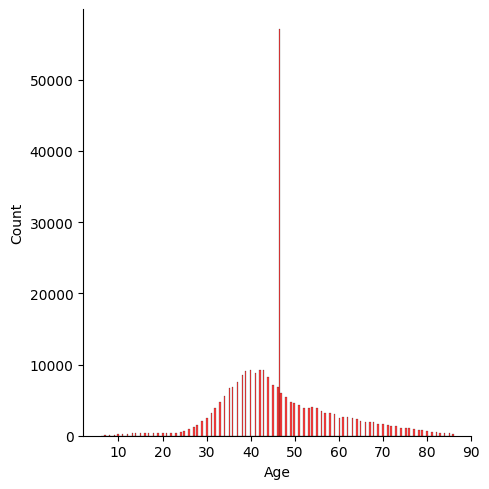

In [36]:
sns.displot(data=df_Benefactors, x='Age', kde=False, color='r')


# Calculate skewness and kurtosis
print(f"\nSkewness of Age: {df_Benefactors['Age'].skew()}")
print(f"Kurtosis of Age: {df_Benefactors['Age'].kurt()}\n")

 **changing the Age distribution is helpful?**



Skewness of Age: 0.09480636827389283
Kurtosis of Age: 1.451734294270243



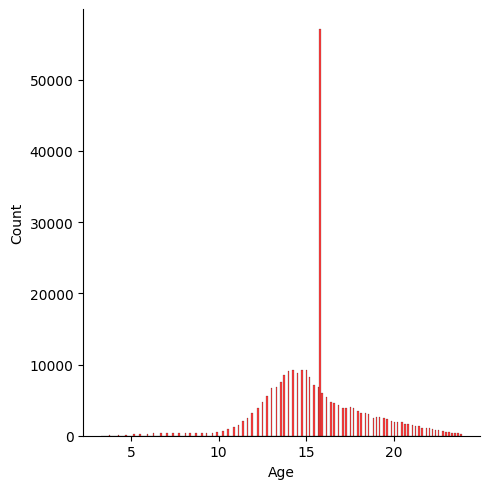

In [37]:
df_Benefactors_copy = df_Benefactors.copy()

from sklearn.preprocessing import PowerTransformer

has_negative_values = (df_Benefactors_copy['Age'] <= 0).any()

if has_negative_values:
    transformer = PowerTransformer(method='yeo-johnson', standardize=False)
else : 
    transformer = PowerTransformer(method='box-cox', standardize=False)
    
# Fit and transform the Age 
df_Benefactors_copy['Age'] = transformer.fit_transform(df_Benefactors_copy[['Age']])

sns.displot(data=df_Benefactors_copy, x='Age', kde=False, color='r')

# Calculate skewness and kurtosis
print(f"\nSkewness of Age: {df_Benefactors_copy['Age'].skew()}")
print(f"Kurtosis of Age: {df_Benefactors_copy['Age'].kurt()}\n")

**Note:** Changing the Age distribution does not help here!!! So discretization can be a good solution! 

**Feature Discretization**

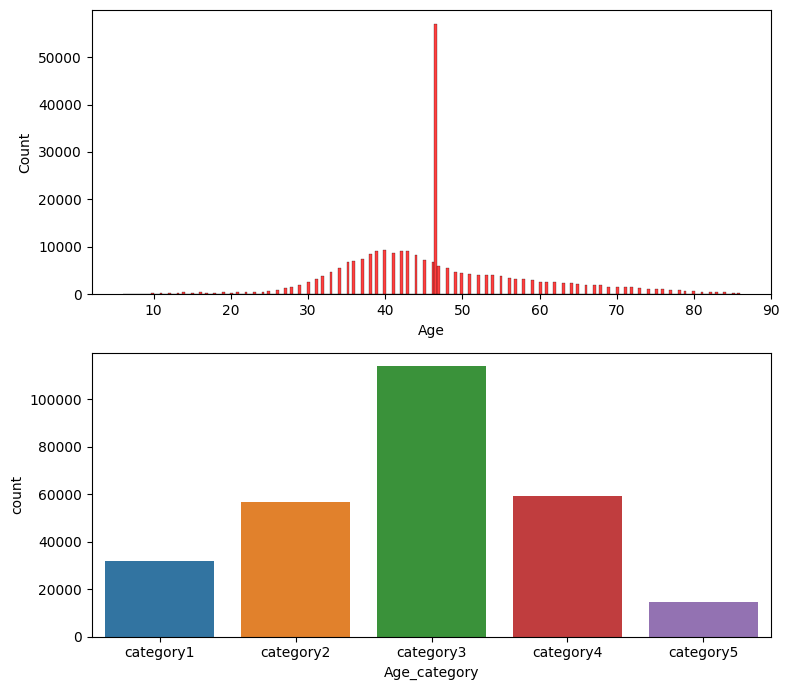

In [38]:

# Define the Age categories
bins = [0, 35, 42, 50, 70, float('inf')]  # These are the bin edges
labels = ['category1', 'category2', 'category3', 'category4', 'category5']  # These are the corresponding labels

# Create a new column 'age_category' with the specified categories
df_Benefactors['Age_category'] = pd.cut(df_Benefactors['Age'], bins=bins, labels=labels, right=False)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 7))
sns.histplot(data=df_Benefactors, x='Age', kde=False, color='r', ax=axes[0])
sns.countplot(x='Age_category', data=df_Benefactors, ax=axes[1])
plt.tight_layout()
plt.show()

**discretization is successful so drop the age field**

In [40]:
df_Benefactors.drop('Age', axis=1, inplace=True)

,UserID,Gender,State,acquaintanceType,Age_category
0,3,female,tehran,ashnayan,category2
1,8,male,tehran,ashnayan,category2
2,14,male,tehran,ashnayan,category3
3,17,female,tehran,ashnayan,category5
4,18,female,tehran,ashnayan,category4
...,...,...,...,...,...
278381,262139,male,tehran,application,category3
278382,262140,male,tehran,application,category3
278383,262141,male,fars,application,category1
278384,262142,female,alborz,tablighat,category3


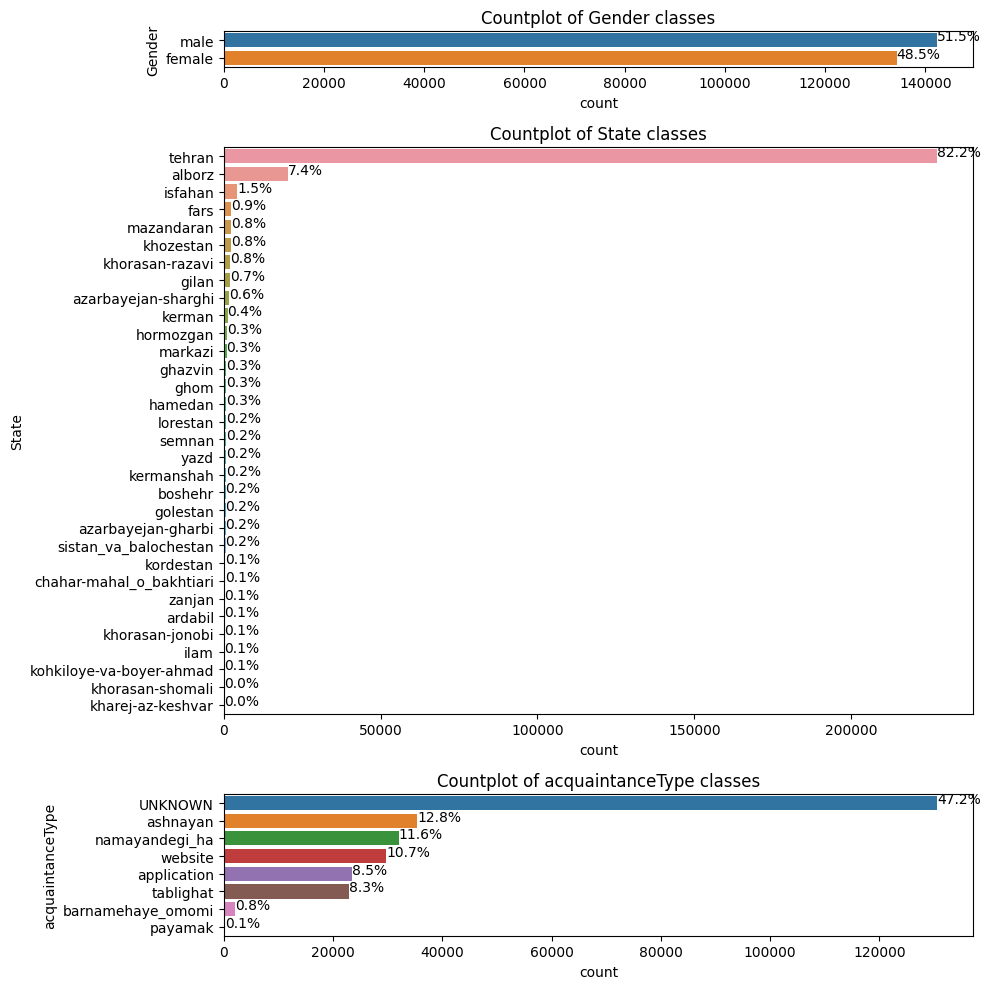

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), 
                         gridspec_kw={'height_ratios': [len(df_Benefactors['Gender'].unique()),
                                                        len(df_Benefactors['State'].unique()),
                                                        len(df_Benefactors['acquaintanceType'].unique())]})

# Function to add percentages
def add_percentage(ax):
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width() / len(df_Benefactors))
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y))
        

sns.countplot(y='Gender', data=df_Benefactors, ax=axes[0], order=df_Benefactors['Gender'].value_counts().index)
add_percentage(axes[0])
axes[0].set_title('Countplot of Gender classes')

sns.countplot(y='State', data=df_Benefactors, ax=axes[1], order=df_Benefactors['State'].value_counts().index)
add_percentage(axes[1])
axes[1].set_title('Countplot of State classes')

sns.countplot(y='acquaintanceType', data=df_Benefactors, ax=axes[2], order=df_Benefactors['acquaintanceType'].value_counts().index)
add_percentage(axes[2])
axes[2].set_title('Countplot of acquaintanceType classes')


plt.tight_layout()
plt.show()

**Combining the smaller classes State and acquaintanceType**

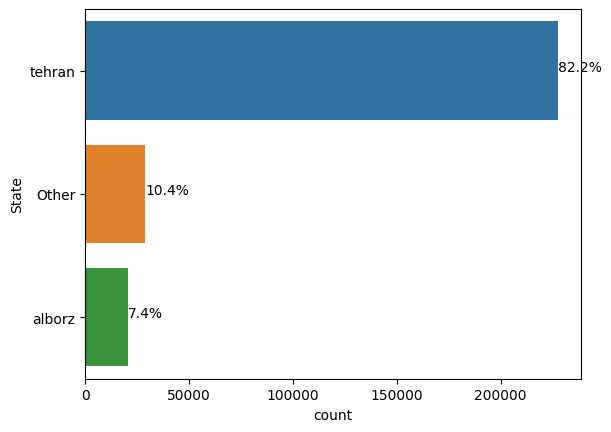

In [42]:
df_Benefactors["State"] = df_Benefactors["State"].apply(lambda x : 'Other' if  x not in ["tehran", "alborz"] else x )

ax = sns.countplot(y='State', data=df_Benefactors, order=df_Benefactors['State'].value_counts().index)
add_percentage(ax)

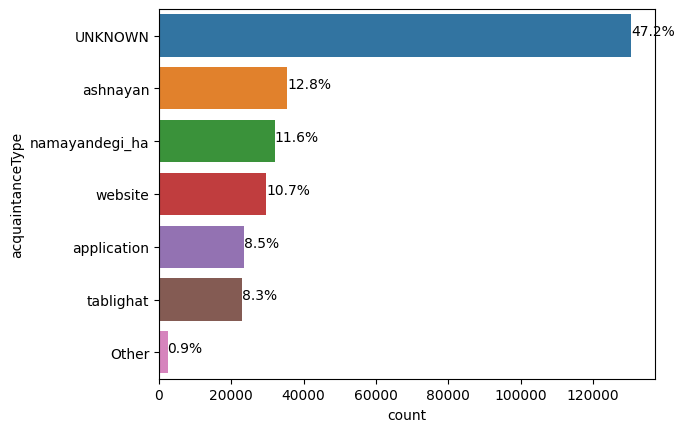

In [43]:
df_Benefactors["acquaintanceType"] = df_Benefactors["acquaintanceType"].apply(lambda x : 'Other' if  x  in ["barnamehaye_omomi", "payamak"] else x )

ax = sns.countplot(y='acquaintanceType', data=df_Benefactors, order=df_Benefactors['acquaintanceType'].value_counts().index)
add_percentage(ax)

# df_Transactions

In [ ]:
df_Transactions = pd.read_csv('TransactionsData.csv')

,TransID,UserID,PaymentDate,PaymentAmount,SupportType
0,850001,174731,2016-03-20,200000,حق عضویت
1,850002,51006,2016-03-20,3000000,نقدی
2,850003,145833,2016-03-20,50000,حق عضویت
3,850004,177032,2016-03-20,22000,حق عضویت
4,850005,147147,2016-03-20,50000,حق عضویت
...,...,...,...,...,...
1490799,2340800,262234,2018-09-08,500000,نقدی
1490800,2340801,278235,2018-09-08,10000,حق عضویت
1490801,2340802,236062,2018-09-08,394000,صندوق خانگی
1490802,2340803,254661,2018-09-08,10000,حق عضویت


**Convert PaymentDate to datetime and check payment date format and inconsistency and check out of logical range**


In [46]:
try:
    df_Transactions['PaymentDate'] = pd.to_datetime(df_Transactions['PaymentDate'])
    print('the PaymentDate format of all our records is ok')
except Exception as e:
    print(f"An error occurred: {e}")
    
print("\nPaymentDate data type is : ", df_Transactions['PaymentDate'].dtypes)

the PaymentDate format of all our records is ok

PaymentDate data type is :  datetime64[ns]


In [47]:
print("Minimum PaymentDate: ", df_Transactions['PaymentDate'].min())
print("Maximum PaymentDate: ", df_Transactions['PaymentDate'].max())

Minimum PaymentDate:  2016-03-20 00:00:00
Maximum PaymentDate:  2018-09-08 00:00:00


**Inconsistent checking**

In [48]:
print(df_Transactions['SupportType'].unique())

['حق عضویت' 'نقدی' 'کمک هزینه' 'صندوق خانگی' 'خرید محصولات']


 **Transliteration**

In [50]:
SupportType_translated_values_dict = {'خرید محصولات':"khardie-mahsolat", 'صندوق خانگی':"sandoghe-khanegi",
                                           'کمک هزینه':"komak-hazine", 'نقدی':"naghdi", 'حق عضویت':"haghe-ozviat"}
 

df_Transactions.iloc[ : , 4] = df_Transactions.iloc[ : , 4].apply(lambda x : SupportType_translated_values_dict.get(x))

,TransID,UserID,PaymentDate,PaymentAmount,SupportType
0,850001,174731,2016-03-20,200000,haghe-ozviat
1,850002,51006,2016-03-20,3000000,naghdi
2,850003,145833,2016-03-20,50000,haghe-ozviat
3,850004,177032,2016-03-20,22000,haghe-ozviat
4,850005,147147,2016-03-20,50000,haghe-ozviat
...,...,...,...,...,...
1490799,2340800,262234,2018-09-08,500000,naghdi
1490800,2340801,278235,2018-09-08,10000,haghe-ozviat
1490801,2340802,236062,2018-09-08,394000,sandoghe-khanegi
1490802,2340803,254661,2018-09-08,10000,haghe-ozviat


 **find  duplicated rows**

In [51]:
if len(df_Transactions[df_Transactions.duplicated(keep='last')]) == 0:
    print("We do not have any duplicate rows !!")
else : 
    print(df_Transactions[df_Transactions.duplicated(keep='last')])

We do not have any duplicate rows !!


**detect out of logical range values**

In [52]:
print(df_Transactions.query('PaymentAmount < 0')['PaymentAmount'].unique().tolist())

[-2147483648]


In [53]:
print(df_Transactions.query('PaymentAmount % 50!=0')['PaymentAmount'].unique().tolist())

[98759, 18384, 4990, 60337, 4038, 7431, 3983, 10833, 1395, 7777, 35806, 35094, 604652, 404053, 67183, 14862, 422205, 103971, 4222, 996647, 77057, 60037, 5212, 4521, 15399508, 76767, 102130, 1674, 725530, 7788, 57133, 47731, 2715, 11881, 10048, 259787, 34678, 78890, 6543, 53638, 444888, 526660, 45458, 38656, 888888, 242320, 53660, 1284, 93007, 113302, 2240, 18264, 100001, 14101, 2749, 4308, 2686, 3186, 15175, 16075, 10009, 122713, 298446, 2140, 3666, 356036, 5010, 58120, 30009, 36589, 58888, 1140, 7795, 166780, 18849, 13294, 1118655961, 478182, 79790, 1024693, 41802, 10166, 1230, 399081, 34271, 2001, 9845, 3366, 2915, 8860, 100002, 57210, 10306, 14645, 99308, 1355, 19462, 6108, 16422, 11039, 13186, 1944, 5652, 7676, 41147, 10310, 21760, 49413, 60009, 428780, 13053, 3626634, 16863, 583839, 2009, 54356, 27549, 3065, 4730, 282883, 23976, 224472, 44953, 8502, 33510, 34334, 12840, 50234, 5480, 7088, 2028, 18030, 85526, 2196, 500009, 29027, 534147, 11777, 17530, 32840, 8646, 232876, 34813, 10

**Attention :** Whether the unit of this currency is Rial or Toman and what values like 1,633,331 are reasonable or not, I only recognized based on my own knowledge, but if an expert in this field was available, we could better and more accurately recognize the values outside the reasonable range.

**Dealing with out of logical range values**

In [54]:
df_Transactions['PaymentAmount'] = df_Transactions['PaymentAmount'].apply(lambda x : x if x>0 and x%50==0 else None)
print("Minimum of PaymentAmount : ", df_Transactions['PaymentAmount'].min())
print("Maximum of PaymentAmount : ", df_Transactions['PaymentAmount'].max())

print("\nNull counts in the PaymentAmount field : ", df_Transactions.PaymentAmount.isnull().sum())

Minimum of PaymentAmount :  50.0
Maximum of PaymentAmount :  1761294000.0

Null counts in the PaymentAmount field :  8172


### Feature Screening

In [55]:
# Calculate the coefficient of variation for "PaymentAmount" column
coefficient_of_variation = df_Transactions['PaymentAmount'].std() / df_Transactions['PaymentAmount'].mean()
print('coefficient of variation for "PaymentAmount" column is ', coefficient_of_variation)

coefficient of variation for "PaymentAmount" column is  7.790997025055396


In [56]:
# Calculate the percentage of the mode category for categorical columns

print("percentage of the mode category for 'SupportType': ", df_Transactions['SupportType'].value_counts().max() / df_Transactions.shape[0] * 100)
print("Null counts of SupportType:",df_Transactions['SupportType'].isnull().sum() / df_Transactions.shape[0] * 100, "\n\n")

percentage of the mode category for 'SupportType':  69.82339730776145
Null counts of SupportType: 0.0 




In [57]:
# Calculate the percentage of uniqueness categories in categorical variables
print("percentage of uniqueness in 'SupportType': ", (len(df_Transactions['SupportType'].unique()) -  int(True in df_Transactions['SupportType'].isnull().unique())) / df_Transactions.shape[0] * 100, "\n")


percentage of uniqueness in 'SupportType':  0.000335389494527785 



**Outlier Detection --> *one dimentional method* (IQR)**

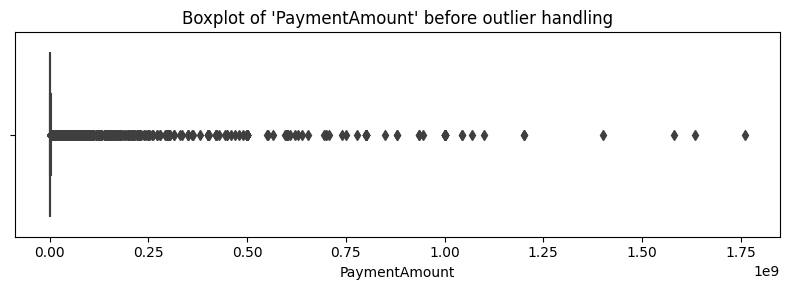

Identified outliers: 112018


In [58]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,3))

# boxplot of 'PaymentAmount'
sns.boxplot(x='PaymentAmount', data=df_Transactions, ax=axes, whis=2)
axes.set_title("Boxplot of 'PaymentAmount' before outlier handling")

# Adjust layout
plt.tight_layout()

# show the plots
plt.show()

# one dimentional method(IQr)
# calculate interquartile range
q25, q75 = df_Transactions['PaymentAmount'].quantile(0.25), df_Transactions['PaymentAmount'].quantile(0.75)
iqr = q75 - q25
  
# calculate the outlier cutoff
cut_off = 2 * iqr 
lower, upper = q25 - cut_off, q75 + cut_off
    
# identify outliers
outliers_of_PaymentAmount= [x for x in df_Transactions['PaymentAmount'] if x < lower or x > upper]
print('Identified outliers: {}'.format(len(outliers_of_PaymentAmount)))

**Missing Checking**

In [59]:
# Create a new column with the number of missing values in each row
df_Transactions['Num_Missing_Values'] = df_Transactions.isnull().sum(axis=1)

# Count and percentage of rows with missing values
df_Transactions_rows_with_missing_values = df_Transactions[df_Transactions['Num_Missing_Values'] > 0]

total_rows = len(df_Transactions)
rows_with_missing_count = len(df_Transactions_rows_with_missing_values)
percentage_rows_with_missing = (rows_with_missing_count / total_rows) * 100


# Display the report
print(f"Total Rows: {total_rows}")
print(f"Rows with Missing Values: {rows_with_missing_count} ({percentage_rows_with_missing:.2f}%)")
print("\n", "-+" * 50, "\n")

# Display the DataFrame with the new column
print("Number of missing cells in each record:\n")
for count, index in zip(df_Transactions[ 'Num_Missing_Values'].value_counts(), df_Transactions[ 'Num_Missing_Values'].value_counts().index):
    print(f'{count} records  have {index} missing cell')
print("\n", "-+" * 50, "\n")

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': df_Transactions.isnull().sum(),
    'Percentage Missing': df_Transactions.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report.iloc[0:-1, :])

Total Rows: 1490804
Rows with Missing Values: 8172 (0.55%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

Number of missing cells in each record:

1482632 records  have 0 missing cell
8172 records  have 1 missing cell

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

count and percentage of missing values in each column:

               Missing Values  Percentage Missing
TransID                     0            0.000000
UserID                      0            0.000000
PaymentDate                 0            0.000000
PaymentAmount            8172            0.548161
SupportType                 0            0.000000


**Remove records with more than 1 missing cells(>50%)**\
These records are of poor quality and are not worth analyzing and modeling

In [60]:
df_Transactions.drop(df_Transactions[df_Transactions[ 'Num_Missing_Values'] > 1].index, inplace=True)

#drop 'Num_Missing_Values' column
df_Transactions.drop('Num_Missing_Values', axis=1, inplace=True)

**Remove records with less than 5% missing values in each column**

In [61]:
for col_label, percentage in zip(df_Transactions.isnull().mean().index, df_Transactions.isnull().mean() * 100):
    if percentage > 0 and percentage < 5:
        df_Transactions.dropna(subset=[col_label], inplace=True)
        
# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': df_Transactions.isnull().sum(),
    'Percentage Missing': df_Transactions.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report)

count and percentage of missing values in each column:

               Missing Values  Percentage Missing
TransID                     0                 0.0
UserID                      0                 0.0
PaymentDate                 0                 0.0
PaymentAmount               0                 0.0
SupportType                 0                 0.0


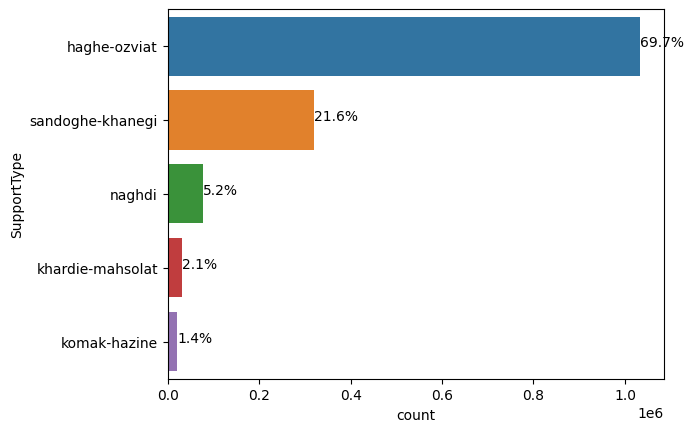

In [62]:
# Function to add percentages
def add_percentage(ax):
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width() / len(df_Transactions))
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y))
        


ax = sns.countplot(y='SupportType', data=df_Transactions, order=df_Transactions['SupportType'].value_counts().index)
add_percentage(ax)

**Combining the smaller classes of the Support Type field**

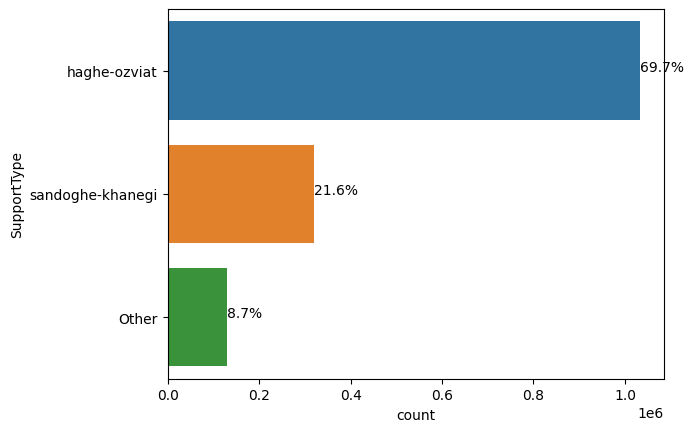

In [63]:
df_Transactions["SupportType"] = df_Transactions["SupportType"].apply(lambda x : 'Other' if  x in ["naghdi", "khardie-mahsolat", "komak-hazine"] else x )

ax = sns.countplot(y='SupportType', data=df_Transactions, order=df_Transactions['SupportType'].value_counts().index)
add_percentage(ax)

**Data Integration**

In [65]:
Integrated_df = pd.merge(df_Benefactors, df_Transactions, on="UserID", how="outer")

,UserID,Gender,State,acquaintanceType,Age_category,TransID,PaymentDate,PaymentAmount,SupportType
0,0,female,alborz,namayandegi_ha,category3,1070281.0,2016-09-13,300000.0,haghe-ozviat
1,0,female,alborz,namayandegi_ha,category3,1666731.0,2017-09-13,500000.0,haghe-ozviat
2,0,female,alborz,namayandegi_ha,category3,2225208.0,2018-07-10,1685000.0,sandoghe-khanegi
3,1,female,Other,website,category2,2174784.0,2018-06-15,150000.0,haghe-ozviat
4,2,male,tehran,UNKNOWN,category2,1092644.0,2016-09-29,1000000.0,Other
...,...,...,...,...,...,...,...,...,...
1482765,278382,male,tehran,UNKNOWN,category3,2099996.0,2018-04-28,455000.0,sandoghe-khanegi
1482766,278383,male,tehran,UNKNOWN,category3,2312277.0,2018-08-25,900000.0,haghe-ozviat
1482767,278384,female,tehran,ashnayan,category3,1044205.0,2016-08-24,731000.0,sandoghe-khanegi
1482768,278385,female,tehran,ashnayan,category3,1101109.0,2016-10-04,1092000.0,sandoghe-khanegi


In [66]:
print(Integrated_df.dtypes)
print("-" * 60)
print("Null counts :\n",Integrated_df.isnull().sum())

UserID                       int64
Gender                      object
State                       object
acquaintanceType            object
Age_category              category
TransID                    float64
PaymentDate         datetime64[ns]
PaymentAmount              float64
SupportType                 object
dtype: object
------------------------------------------------------------
Null counts :
 UserID                 0
Gender              8418
State               8418
acquaintanceType    8418
Age_category        8418
TransID              138
PaymentDate          138
PaymentAmount        138
SupportType          138
dtype: int64


**Missing Checking**

In [67]:
# Create a new column with the number of missing values in each row
Integrated_df['Num_Missing_Values'] = Integrated_df.isnull().sum(axis=1)

# Count and percentage of rows with missing values
Integrated_df_rows_with_missing_values = Integrated_df[Integrated_df['Num_Missing_Values'] > 0]

total_rows = len(Integrated_df)
rows_with_missing_count = len(Integrated_df_rows_with_missing_values)
percentage_rows_with_missing = (rows_with_missing_count / total_rows) * 100


# Display the report
print(f"Total Rows: {total_rows}")
print(f"Rows with Missing Values: {rows_with_missing_count} ({percentage_rows_with_missing:.2f}%)")
print("\n", "-+" * 50, "\n")

# Display the DataFrame with the new column
print("Number of missing cells in each record:\n")
for count, index in zip(Integrated_df[ 'Num_Missing_Values'].value_counts(), Integrated_df[ 'Num_Missing_Values'].value_counts().index):
    print(f'{count} records  have {index} missing cell')
print("\n", "-+" * 50, "\n")

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': Integrated_df.isnull().sum(),
    'Percentage Missing': Integrated_df.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report.iloc[0:-1, :])

Total Rows: 1482770
Rows with Missing Values: 8556 (0.58%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

Number of missing cells in each record:

1474214 records  have 0 missing cell
8556 records  have 4 missing cell

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ 

count and percentage of missing values in each column:

                  Missing Values  Percentage Missing
UserID                         0            0.000000
Gender                      8418            0.567721
State                       8418            0.567721
acquaintanceType            8418            0.567721
Age_category                8418            0.567721
TransID                      138            0.009307
PaymentDate                  138            0.009307
PaymentAmount                138            0.009307
SupportType                  138            0.009307


**Remove records with more than 4 missing cells(>50%)**\
These records are of poor quality and are not worth analyzing and modeling

In [68]:
Integrated_df.drop(Integrated_df[Integrated_df[ 'Num_Missing_Values'] > 4].index, inplace=True)

#drop 'Num_Missing_Values' column
Integrated_df.drop('Num_Missing_Values', axis=1, inplace=True)

**Remove records with less than 5% missing values in each column**

In [69]:
for col_label, percentage in zip(Integrated_df.isnull().mean().index, Integrated_df.isnull().mean() * 100):
    if percentage > 0 and percentage < 5:
        Integrated_df.dropna(subset=[col_label], inplace=True)
        
# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Missing Values': Integrated_df.isnull().sum(),
    'Percentage Missing': Integrated_df.isnull().mean() * 100
})

# Display the missing values report
print("count and percentage of missing values in each column:\n")
print(missing_values_report)

count and percentage of missing values in each column:

                  Missing Values  Percentage Missing
UserID                         0                 0.0
Gender                         0                 0.0
State                          0                 0.0
acquaintanceType               0                 0.0
Age_category                   0                 0.0
TransID                        0                 0.0
PaymentDate                    0                 0.0
PaymentAmount                  0                 0.0
SupportType                    0                 0.0


**Data Aggregation: RFM Analysis**

In [71]:
aggregated_df = pd.DataFrame()

# Recency can be calculated as the count of transactions for each ID
aggregated_df['recency'] = Integrated_df.groupby('UserID')['PaymentDate'].max().apply(lambda x: (Integrated_df['PaymentDate'].max() - x).days)

# Frequency can be calculated as the count of transactions for each ID
aggregated_df['frequency'] = Integrated_df.groupby('UserID').size()

# Monetary can be calculated as the sum of monetary values for each ID
aggregated_df['monetary'] = Integrated_df.groupby('UserID')['PaymentAmount'].sum()

# Calculate the duration of the minimum and maximum transactions for each ID
min_date = Integrated_df.groupby('UserID')['PaymentDate'].min()
max_date = Integrated_df.groupby('UserID')['PaymentDate'].max()
aggregated_df['duration'] = (max_date - min_date).dt.days + 1

# Gender can be taken as the mode value for each ID
aggregated_df['Gender'] = Integrated_df.groupby('UserID')['Gender'].apply(lambda x: ''.join(list(x.mode())))

# State can be taken as the mode value for each ID
aggregated_df['State'] = Integrated_df.groupby('UserID')['State'].apply(lambda x: ''.join(list(x.mode())))

# acquaintanceType can be taken as the mode value for each ID
aggregated_df['acquaintanceType'] = Integrated_df.groupby('UserID')['acquaintanceType'].apply(lambda x: ''.join(list(x.mode())))

# Age_category can be taken as the mode value for each ID
aggregated_df['Age_category'] = Integrated_df.groupby('UserID')['Age_category'].apply(lambda x: ''.join(list(x.mode())))

# SupportType can be taken as the mode value for each ID
aggregated_df['SupportType'] = Integrated_df.groupby('UserID')['SupportType'].apply(lambda x: ''.join(list(x.mode())))




**Create RFM Scores**

In [ ]:
aggregated_df['RecencyScore'] = pd.cut(aggregated_df['recency'], bins=[0, 60, 180, 365, 545, float('inf')], labels=[5, 4, 3, 2, 1], right=False)

aggregated_df['FrequencyScore'] = pd.cut(aggregated_df['frequency'], bins=[1, 2, 5, 10, 20, float('inf')], labels=[1, 2, 3, 4, 5], right=False)

aggregated_df['MonetaryScore'] = pd.cut(aggregated_df['monetary'], bins=[0, 500000, 1200000, 2500000, 10000000, float('inf')], labels=[1, 2, 3, 4, 5], right=False)

aggregated_df['DurationScore'] = pd.cut(aggregated_df['duration'], bins=[0, 1, 180, 365, 545, float('inf')], labels=[1, 2, 3, 4, 5], right=False)

In [ ]:
aggregated_df.to_csv('aggregated_df.csv', index=False)

In [82]:
aggregated_df = pd.read_csv('/kaggle/input/aggregated-df/aggregated_df.csv') 

,recency,frequency,monetary,duration,Gender,State,acquaintanceType,Age_category,SupportType,RecencyScore,FrequencyScore,MonetaryScore,DurationScore
0,60,3,2485000.0,666,female,alborz,namayandegi_ha,category3,haghe-ozviat,4,2,3,5
1,85,1,150000.0,1,female,Other,website,category2,haghe-ozviat,4,1,1,2
2,709,1,1000000.0,1,male,tehran,UNKNOWN,category2,Other,1,1,2,2
3,28,21,8476500.0,825,female,tehran,ashnayan,category2,sandoghe-khanegi,5,5,4,5
4,19,1,500000.0,1,female,tehran,UNKNOWN,category5,Other,5,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
276516,422,2,2256500.0,320,male,tehran,UNKNOWN,category3,sandoghe-khanegi,2,2,3,3
276517,133,3,5468250.0,480,male,tehran,UNKNOWN,category3,sandoghe-khanegi,4,2,4,4
276518,14,1,900000.0,1,male,tehran,UNKNOWN,category3,haghe-ozviat,5,1,2,2
276519,745,1,731000.0,1,female,tehran,ashnayan,category3,sandoghe-khanegi,1,1,2,2


**Note:** Due to memory limitations in processing a dataset of 270,000 samples, 10% of the data was randomly sampled and used for clustering.

**Random Sampling**

In [84]:
aggregated_df_sample = aggregated_df.sample(frac=0.1, random_state=42) 

,recency,frequency,monetary,duration,Gender,State,acquaintanceType,Age_category,SupportType,RecencyScore,FrequencyScore,MonetaryScore,DurationScore
152453,594,1,100000.0,1,female,tehran,website,category1,haghe-ozviat,1,1,1,2
10901,21,1,986000.0,1,female,tehran,UNKNOWN,category3,sandoghe-khanegi,5,1,2,2
234250,465,1,1000000.0,1,male,tehran,namayandegi_ha,category3,Other,2,1,2,2
33145,7,15,12500000.0,882,female,alborz,namayandegi_ha,category4,Other,5,4,5,5
25572,3,22,3220000.0,815,male,tehran,UNKNOWN,category4,haghe-ozviat,5,5,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,430,1,1888000.0,1,male,tehran,UNKNOWN,category2,sandoghe-khanegi,2,1,3,2
65280,252,24,1170000.0,620,male,alborz,UNKNOWN,category3,haghe-ozviat,3,5,2,5
171052,270,2,9586000.0,372,female,tehran,UNKNOWN,category2,sandoghe-khanegi,3,2,4,4
39046,213,1,200000.0,1,female,tehran,ashnayan,category2,haghe-ozviat,3,1,1,2


In [86]:
def clusterSummeryFunc(X_hierarchical):
    # Group by cluster and calculate the mean for each score 
    cluster_summery = X_hierarchical.groupby('cluster').mean().reset_index()

    # Calculate the number of records and percentage for each cluster 
    cluster_counts = X_hierarchical['cluster'].value_counts().reset_index()
    cluster_counts.columns = ['cluster', 'count']
    cluster_counts['percentage'] = (cluster_counts['count'] / len(X_hierarchical)) * 100

    # Calculate the overall mena for each score 
    overall_mean = X_hierarchical[['RecencyScore', 'FrequencyScore', 'MonetaryScore', 'DurationScore', 'silhouette']].mean().to_frame().T
    overall_mean['cluster'] = "All Data"
    overall_mean['count'] = len(X_hierarchical)
    overall_mean['percentage'] = 100

    # Rename columns indicate they are mean values 
    cluster_summery.columns = ['cluster', 'mean_RecencyScore', 'mean_FrequencyScore', 'mean_MonetaryScore', 'mean_DurationScore', 'mean_Silhouette']

    # Merge cluster_summary with cluster_counts
    cluster_summery = pd.merge(cluster_summery, cluster_counts, on='cluster')

    # Append the overall mean to the cluster summary
    overall_mean.columns = ['mean_RecencyScore', 'mean_FrequencyScore', 'mean_MonetaryScore', 'mean_DurationScore', 'mean_Silhouette', 'cluster', 'count', 'percentage']

    return cluster_summery

**AgglomerativeClustering**

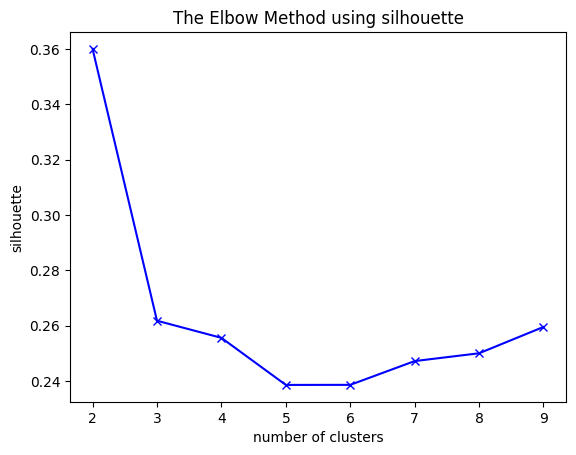

In [89]:
X = aggregated_df_sample[["RecencyScore", "FrequencyScore", "MonetaryScore", "DurationScore"]]

# Define the range of cluster numbers to test 
cluster_range = range(2,10)

# List to store silhouette scores
silhouette_scores = []
all_clusters_summery = pd.DataFrame(columns=['cluster', 'mean_RecencyScore', 'mean_FrequencyScore', 'mean_MonetaryScore', 'mean_DurationScore', 'mean_Silhouette', 'count', 'percentage'])
all_clusters_summery.loc[0] =  ['Cluster2'] * len(all_clusters_summery.columns)



# Calculate silhouette for each cluster number
for n_clusters in cluster_range:
    
    # random.seed(42)
    # Initialize the AgglomerativeClustering model 
    hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters, metric="euclidean", linkage='ward', distance_threshold=None, compute_distances=False)

    # Fit the model and predict the cluster labels
    labels = hierarchical_model.fit_predict(X)
    # Compute the silhouette score 
    silhouette_avg = silhouette_score(X , labels)
    
    silhouette_scores.append(silhouette_avg)

    X_hierarchical = X.copy()
    X_hierarchical['cluster'] = labels
    X_hierarchical['silhouette'] = silhouette_samples(X , labels)
    
    all_clusters_summery = pd.concat([all_clusters_summery, clusterSummeryFunc(X_hierarchical)], ignore_index=True)
    all_clusters_summery.loc[len(all_clusters_summery)] =  [f'Cluster{n_clusters + 1 }'] * len(all_clusters_summery.columns)
       
    
plt.plot(cluster_range, silhouette_scores, 'bx-')
plt.xlabel('number of clusters')
plt.ylabel('silhouette')
plt.title('The Elbow Method using silhouette')
plt.show()

In [90]:
all_clusters_summery

,cluster,mean_RecencyScore,mean_FrequencyScore,mean_MonetaryScore,mean_DurationScore,mean_Silhouette,count,percentage
0,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2
1,0,2.404475,1.460119,2.52529,2.422932,0.341741,18367,66.421959
2,1,4.348196,2.976844,3.610985,4.506731,0.396399,9285,33.578041
3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3
4,0,2.42642,1.305748,1.778134,2.168023,0.251813,11552,41.776363
5,1,4.348196,2.976844,3.610985,4.506731,0.285099,9285,33.578041
6,2,2.367278,1.72179,3.791783,2.855026,0.246737,6815,24.645595
7,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4
8,0,4.348196,2.976844,3.610985,4.506731,0.26899,9285,33.578041
9,1,3.283523,1.479404,1.752118,2.283523,0.109643,6846,24.757703


**KMeans**

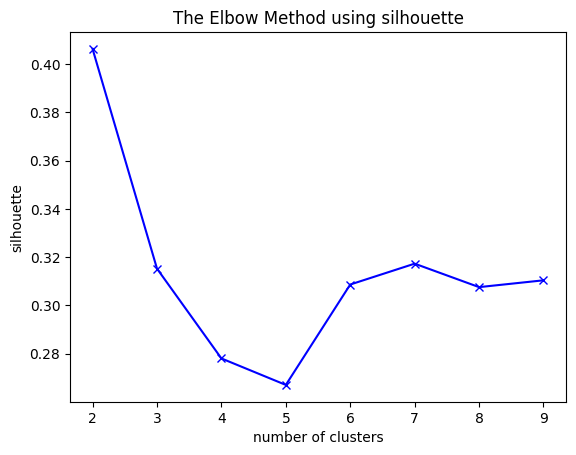

In [93]:

# Define the range of cluster numbers to test 
cluster_range = range(2,10)

# List to store silhouette scores
silhouette_scores_for_kmeans = []

all_clusters_summery_for_kmeans = pd.DataFrame(columns=['cluster', 'mean_RecencyScore', 'mean_FrequencyScore', 'mean_MonetaryScore', 'mean_DurationScore', 'mean_Silhouette', 'count', 'percentage'])
all_clusters_summery_for_kmeans.loc[0] =  ['Cluster2'] * len(all_clusters_summery_for_kmeans.columns)


# Calculate silhouette for each cluster number
for n_clusters in cluster_range:
    
    # random.seed(42)
    # Initialize the KMeans model
    kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, random_state=111, algorithm='lloyd')
    # Fit the model
    kmeans_model.fit(X)
    # predict the cluster labels
    labels = kmeans_model.predict(X)

    # Compute the silhouette score 
    silhouette_avg = silhouette_score(X, labels)
    
    silhouette_scores_for_kmeans.append(silhouette_avg)

    X_kmean = X.copy()
    X_kmean['cluster'] = labels
    X_kmean['silhouette'] = silhouette_samples(X , labels)
    
    all_clusters_summery_for_kmeans = pd.concat([all_clusters_summery_for_kmeans, clusterSummeryFunc(X_kmean)], ignore_index=True)
    all_clusters_summery_for_kmeans.loc[len(all_clusters_summery_for_kmeans)] =  [f'Cluster{n_clusters + 1 }'] * len(all_clusters_summery_for_kmeans.columns)
       
    
plt.plot(cluster_range, silhouette_scores_for_kmeans, 'bx-')
plt.xlabel('number of clusters')
plt.ylabel('silhouette')
plt.title('The Elbow Method using silhouette')
plt.show()

In [94]:
all_clusters_summery_for_kmeans

,cluster,mean_RecencyScore,mean_FrequencyScore,mean_MonetaryScore,mean_DurationScore,mean_Silhouette,count,percentage
0,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2,Cluster2
1,0,2.283629,1.322659,2.262667,2.178498,0.433217,15552,56.241863
2,1,4.051322,2.800661,3.69595,4.336116,0.371855,12100,43.758137
3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3,Cluster3
4,0,1.824298,1.383687,3.285485,2.277846,0.312559,8116,29.350499
5,1,4.147529,2.871578,3.719364,4.460959,0.361199,10886,39.367858
6,2,2.841618,1.383584,1.474682,2.230983,0.259879,8650,31.281643
7,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4,Cluster4
8,0,1.44404,1.306001,3.189949,2.134568,0.403903,6049,21.875452
9,1,4.554734,3.983834,3.678753,4.754734,0.263915,4330,15.658904


**Note:** the best number of clusters is 4 from the agglomerative algorithm


cluster**0** > **loyal_customers**

cluster**1** > **need_attention**

cluster**2** > **valuable_inactives**

cluster**3** > **passed_customers**


In [95]:
# Initialize the Agglomerative model with 4 clusters
ha_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward', distance_threshold=None, compute_distances=False)

X = aggregated_df_sample[["RecencyScore", "FrequencyScore", "MonetaryScore", "DurationScore"]]

# Fit the model and predict the cluster labels
labels = ha_model.fit_predict(X)

# Compute the silhouette score 
silhouette_avg = silhouette_score(X , labels)
silhouette = silhouette_samples(X, labels)

X_ha = X.copy()
X_ha['cluster'] = labels
X_ha['silhouette'] = silhouette

clusterSummeryFunc(X_ha)

,cluster,mean_RecencyScore,mean_FrequencyScore,mean_MonetaryScore,mean_DurationScore,mean_Silhouette,count,percentage
0,0,4.348196,2.976844,3.610985,4.506731,0.268990,9285,33.578041
1,1,3.283523,1.479404,1.752118,2.283523,0.109643,6846,24.757703
2,2,2.367278,1.721790,3.791783,2.855026,0.172359,6815,24.645595
3,3,1.179558,1.053124,1.815980,2.000000,0.561718,4706,17.018660


In [97]:
df_with_customer_label = aggregated_df_sample.copy()
# 1 means "VIP customer" and 0 means "regular customer"
df_with_customer_label['Customer_label'] = [1 if label == 0 else 0 for label in labels]

,recency,frequency,monetary,duration,Gender,State,acquaintanceType,Age_category,SupportType,RecencyScore,FrequencyScore,MonetaryScore,DurationScore,Customer_label
152453,594,1,100000.0,1,female,tehran,website,category1,haghe-ozviat,1,1,1,2,0
10901,21,1,986000.0,1,female,tehran,UNKNOWN,category3,sandoghe-khanegi,5,1,2,2,0
234250,465,1,1000000.0,1,male,tehran,namayandegi_ha,category3,Other,2,1,2,2,0
33145,7,15,12500000.0,882,female,alborz,namayandegi_ha,category4,Other,5,4,5,5,1
25572,3,22,3220000.0,815,male,tehran,UNKNOWN,category4,haghe-ozviat,5,5,4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,430,1,1888000.0,1,male,tehran,UNKNOWN,category2,sandoghe-khanegi,2,1,3,2,0
65280,252,24,1170000.0,620,male,alborz,UNKNOWN,category3,haghe-ozviat,3,5,2,5,1
171052,270,2,9586000.0,372,female,tehran,UNKNOWN,category2,sandoghe-khanegi,3,2,4,4,0
39046,213,1,200000.0,1,female,tehran,ashnayan,category2,haghe-ozviat,3,1,1,2,0


In [99]:
df_demographic_features_and_customer_label = df_with_customer_label[["Gender", "State", "acquaintanceType", "Age_category", "SupportType", "Customer_label"]]

,Gender,State,acquaintanceType,Age_category,SupportType,Customer_label
152453,female,tehran,website,category1,haghe-ozviat,0
10901,female,tehran,UNKNOWN,category3,sandoghe-khanegi,0
234250,male,tehran,namayandegi_ha,category3,Other,0
33145,female,alborz,namayandegi_ha,category4,Other,1
25572,male,tehran,UNKNOWN,category4,haghe-ozviat,1
...,...,...,...,...,...,...
28995,male,tehran,UNKNOWN,category2,sandoghe-khanegi,0
65280,male,alborz,UNKNOWN,category3,haghe-ozviat,1
171052,female,tehran,UNKNOWN,category2,sandoghe-khanegi,0
39046,female,tehran,ashnayan,category2,haghe-ozviat,0


In [100]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Apply Label Encoding to multiple columns (A, B, C)
for column in ['Gender', 'State', 'acquaintanceType', 'SupportType']:
    df_demographic_features_and_customer_label[column] = label_encoder.fit_transform(df_demographic_features_and_customer_label[column])
    
    
from sklearn.preprocessing import OrdinalEncoder

# Create an OrdinalEncoder object
ordinal_encoder = OrdinalEncoder()

# Apply Ordinal Encoding
df_demographic_features_and_customer_label['Age_category'] = ordinal_encoder.fit_transform(df_demographic_features_and_customer_label[['Age_category']])

df_demographic_features_and_customer_label

,Gender,State,acquaintanceType,Age_category,SupportType,Customer_label
152453,0,2,6,0.0,4,0
10901,0,2,1,2.0,6,0
234250,1,2,4,2.0,0,0
33145,0,1,4,3.0,0,1
25572,1,2,1,3.0,4,1
...,...,...,...,...,...,...
28995,1,2,1,1.0,6,0
65280,1,1,1,2.0,4,1
171052,0,2,1,1.0,6,0
39046,0,2,3,1.0,4,0


**train-test splitting**

In [101]:
X = df_demographic_features_and_customer_label.iloc[:, [0,1,2,3,4]]
y = df_demographic_features_and_customer_label.iloc[:, [-1]]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [102]:
df_demographic_features_and_customer_label['Customer_label'].value_counts()

Customer_label
0    18367
1     9285
Name: count, dtype: int64

**Random Over Sampling**


In [103]:
from imblearn.over_sampling import RandomOverSampler

# Perform random oversampling 
ros = RandomOverSampler(random_state=0)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

y_train_ros.value_counts()

Customer_label
0                 12866
1                 12866
Name: count, dtype: int64

**attention :** we have categorical data, but our model needs something numerical

**Decision Tree model**

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score 

# Create a decision tree classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=20, min_samples_leaf=10, min_weight_fraction_leaf=0,
                            random_state=42, min_impurity_decrease=0, class_weight="balanced", ccp_alpha=0)

# Train the classifier on the training data
clf.fit(X_train_ros, y_train_ros)

# predict the labels for the test set 
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

# Evaluate the model 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for test set:", accuracy)

Accuracy for test set: 0.6024590163934426


**Checking the Overfitting**

In [105]:
# Predict on the training set 
y_train_pred = clf.predict(X_train_ros)

# Predict on the test set 
y_test_pred = clf.predict(X_test)

# Calculate accuracy for the train and test sets 
accuracy_train = accuracy_score(y_train_ros, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Calculate the difference in accuracy between train and test sets 
accuracy_diff = accuracy_train - accuracy_test 

print("Accuracy for train set:", accuracy_train)
print("Accuracy for test set:", accuracy_test)
print("Difference in accuracy between train and test sets:", accuracy_diff)

Accuracy for train set: 0.5710788123736981
Accuracy for test set: 0.6024590163934426
Difference in accuracy between train and test sets: -0.031380204019744506


**Note :** the difference is less than 5 percent,so the model is  not overfitted.

**Confusion Matrix**

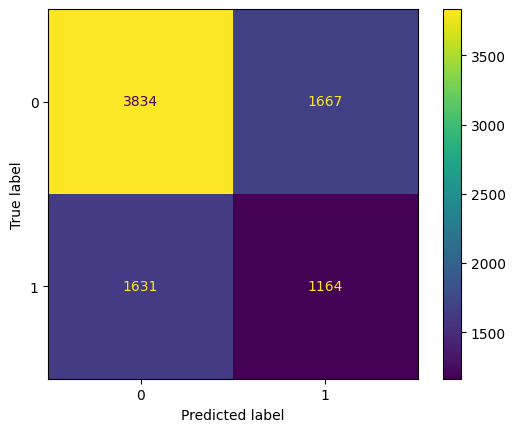

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix 
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=clf.classes_)
disp.plot()
plt.show()

**Hyperparameters Tuning**

In [107]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer


# Define a custom scorer for class '1' F1-score 
custom_scorer = make_scorer(f1_score, lables=['1'], average=None)

# Define the parameter grid 
param_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25], 
    'min_samples_split' : [5, 8, 10, 15, 20, 25, 30],
    'min_samples_leaf' : [5, 7, 9, 11, 13, 15, 20, 25],
    'class_weight': [None, 'balanced']
}

#Instantiate the DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=111)

# Instantiate GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring=custom_scorer)

# Perform GridSearchCV
grid_search.fit(X_train_ros, y_train_ros)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters: ", best_params)

# Get the best estimator
best_clf = grid_search.best_estimator_

# Evaluate the best estimator on the test set 
accuracy = best_clf.score(X_test, y_test)
print("Test Accuracy: ", accuracy)


Best Parameters:  {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 5}
Test Accuracy:  0.6024590163934426


**Visualize the Decision Tree and If-Then Rules**

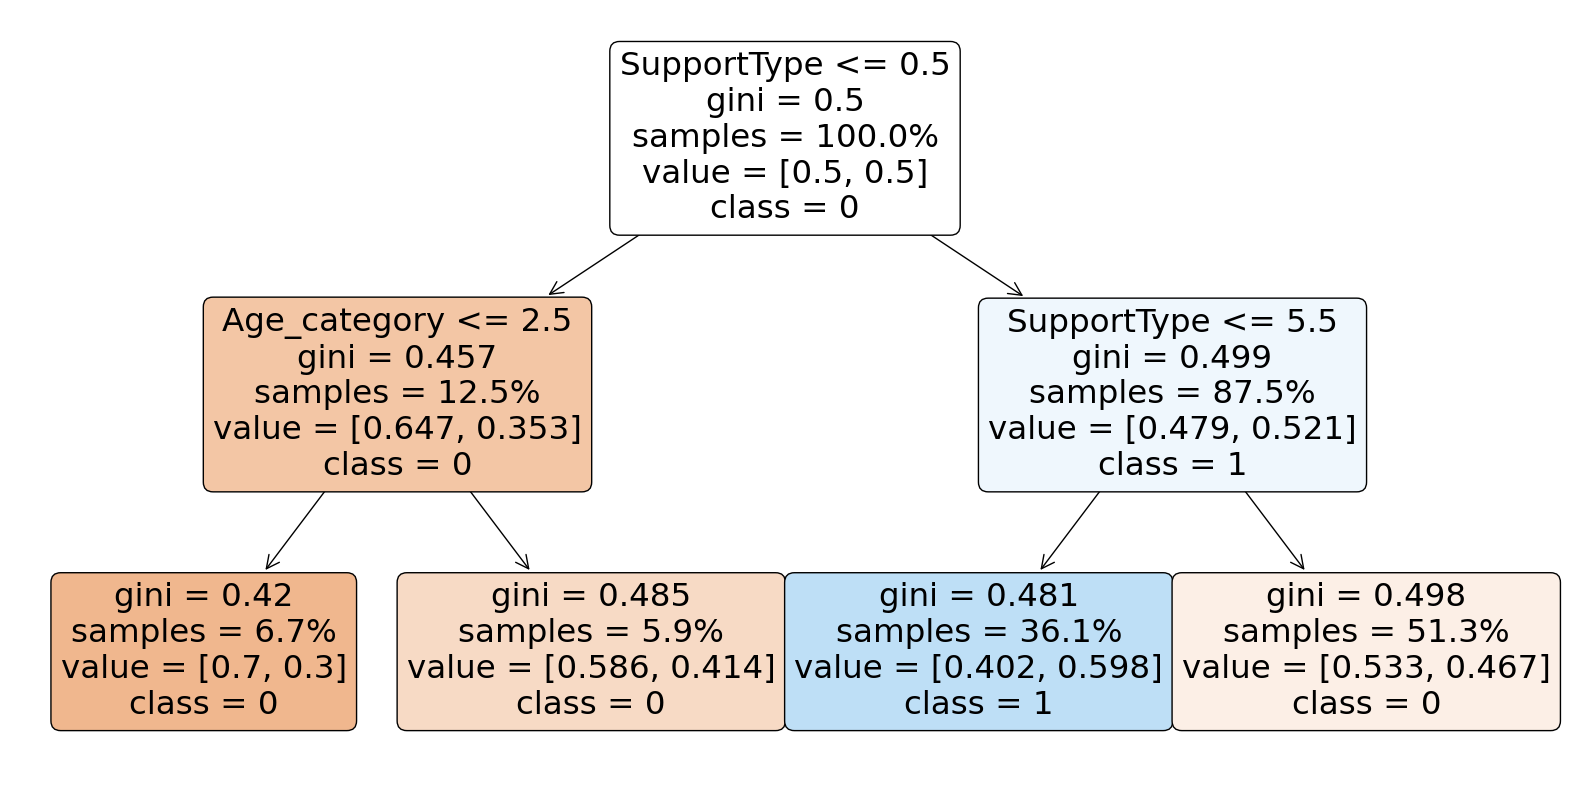

In [108]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10)) 
plot_tree(best_clf, feature_names=best_clf.feature_names_in_, 
          class_names=[str(cls) for cls in best_clf.classes_],  # Convert class names to strings
          proportion=True, filled=True, rounded=True)

plt.show()

**Decision Tree and If-Then Rules**

In [109]:
from sklearn.tree import export_text

tree_rules = export_text(best_clf, feature_names=list(best_clf.feature_names_in_), spacing=3, decimals=2, show_weights=False)

print(tree_rules)

|--- SupportType <= 0.50
|   |--- Age_category <= 2.50
|   |   |--- class: 0
|   |--- Age_category >  2.50
|   |   |--- class: 0
|--- SupportType >  0.50
|   |--- SupportType <= 5.50
|   |   |--- class: 1
|   |--- SupportType >  5.50
|   |   |--- class: 0

